## Imports & Setup

In [52]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt

# RDKit
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors, rdFingerprintGenerator, rdPartialCharges
from rdkit.Chem.Scaffolds import MurckoScaffold

# PyTorch + PyG
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, Subset
import torch.nn.functional as F
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.nn import GINEConv, AttentiveFP, global_mean_pool, global_add_pool, GINConv

# sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# MLflow
import mlflow
import mlflow.pytorch

# Misc
import json
import math
import copy
import os

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print('Setup complete.')

Setup complete.


In [ ]:
# Paths
DATA_DIR  = Path('./data')
DATA_DIR.mkdir(exist_ok=True)

RAW_PARQUET = 'C:\\Users\\natalia\\Documents\\Studia\\Warsztaty_sztucznej_inteligencji\\Warsztaty_sztucznej_inteligencji\\data\\chembl_joined_2147_20260604_215317.parquet' # raw ChEMBL export
MLP_PARQUET = DATA_DIR / 'mlp_features_2147_mlp.parquet' # prepared MLP features
GNN_PT = DATA_DIR / 'gnn_graphs_2147_gnn.pt' # prepared GNN graphs


# Part 1 - Data Preparation

- Light cleaning
- Deduplicate by SMILES → median pic50
- Build Morgan fingerprint + physicochemical feature matrix for MLP
- Build atom/bond graph objects for GNN

### 1.1 Load & minimal clean

In [21]:
df_raw = pd.read_parquet(RAW_PARQUET)
print(f'Raw rows: {len(df_raw):,}')
print(df_raw.dtypes)
df_raw.head(3)

Raw rows: 2,522
activity_id               int64
molregno                  int64
standard_value          float64
standard_units           object
standard_type            object
standard_relation        object
pchembl_value           float64
pic50                   float64
has_validity_comment       bool
assay_type               object
assay_organism           object
assay_relationship       object
confidence_score          int64
target_chembl_id         object
target_name              object
organism                 object
canonical_smiles         object
mw_freebase             float64
alogp                   float64
hba                     float64
hbd                     float64
psa                     float64
rtb                     float64
aromatic_rings          float64
qed_weighted            float64
dtype: object


,activity_id,molregno,standard_value,standard_units,standard_type,standard_relation,pchembl_value,pic50,has_validity_comment,assay_type,...,organism,canonical_smiles,mw_freebase,alogp,hba,hbd,psa,rtb,aromatic_rings,qed_weighted
0,1723376,349203,9200.0,nM,Ki,>,NaN,5.036212,False,B,...,homo sapiens,CCOc1nc(NC(C)=O)cc(N)c1C#N,220.23,0.89,5.0,2.0,101.03,3.0,1.0,0.79
1,1723466,349994,9200.0,nM,Ki,>,NaN,5.036212,False,B,...,homo sapiens,CCOc1nc(NC(=O)Cc2cc(OC)c(S(C)(=O)=O)cc2OC)cc(N...,443.91,2.32,8.0,2.0,129.84,8.0,2.0,0.64
2,1723467,349217,9200.0,nM,Ki,>,NaN,5.036212,False,B,...,homo sapiens,CC(=O)Nc1cc(N)c(C#N)c(-c2ccccc2)n1,252.28,2.16,4.0,2.0,91.80,2.0,2.0,0.86


In [22]:
# Double check after initial data load: drop rows without a SMILES or pic50
df = df_raw.dropna(subset=['canonical_smiles', 'pic50']).copy()
print(f'After dropping null SMILES/pic50: {len(df):,}')

# RDKit-validate SMILES
def canonicalise(smi: str):
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol) if mol else None

df['canonical_smiles'] = df['canonical_smiles'].apply(canonicalise)
invalid = df['canonical_smiles'].isna().sum()
df = df.dropna(subset=['canonical_smiles'])
print(f'Invalid SMILES dropped: {invalid} \nRemaining: {len(df):,}')


# Deduplicate — median pic50 per canonical SMILES
# Aggregate physicochemical columns by taking the first, casue they should be the same for each SMILES
physchem_cols = ['mw_freebase','alogp','hba','hbd','psa','rtb','aromatic_rings','qed_weighted']
physchem_first = df.groupby('canonical_smiles')[physchem_cols].first()
pic50_median   = df.groupby('canonical_smiles')['pic50'].median().rename('pic50')
pic50_std      = df.groupby('canonical_smiles')['pic50'].std().rename('pic50_std')
n_measurements = df.groupby('canonical_smiles')['pic50'].count().rename('n_measurements')

df_dedup = pd.concat([pic50_median, pic50_std, n_measurements, physchem_first], axis=1).reset_index()

# Canonical global index for later correct splitting for both MLP and GNN datasets
df_dedup = df_dedup.reset_index(drop=True)
df_dedup["mol_id"] = np.arange(len(df_dedup))

print(f'After deduplication: {len(df_dedup):,} unique compounds')
df_dedup.describe()


After dropping null SMILES/pic50: 2,522
Invalid SMILES dropped: 0 
Remaining: 2,522
After deduplication: 2,222 unique compounds


,pic50,pic50_std,n_measurements,mw_freebase,alogp,hba,hbd,psa,rtb,aromatic_rings,qed_weighted,mol_id
count,2222.000000,187.000000,2222.000000,2222.000000,2219.000000,2219.000000,2219.000000,2219.000000,2219.000000,2219.000000,2219.000000,2222.00000
mean,6.926704,0.551555,1.135014,394.283258,3.557337,5.542587,1.949076,82.600442,3.913024,3.147364,0.582190,1110.50000
std,1.784842,0.475986,0.900122,79.652025,1.176226,1.697971,0.889080,24.000895,2.043951,1.076600,0.156596,641.58047
min,1.247867,0.000000,1.000000,162.140000,-0.740000,0.000000,0.000000,6.480000,0.000000,0.000000,0.080000,0.00000
25%,5.202396,0.230233,1.000000,346.182500,2.790000,4.000000,1.000000,66.490000,3.000000,2.000000,0.480000,555.25000
50%,6.987163,0.337376,1.000000,391.420000,3.510000,5.000000,2.000000,80.900000,4.000000,3.000000,0.580000,1110.50000
75%,8.221849,0.822269,1.000000,440.420000,4.325000,7.000000,2.000000,94.900000,5.000000,4.000000,0.700000,1665.75000
max,12.000000,2.224648,34.000000,1030.300000,7.740000,14.000000,8.000000,208.120000,20.000000,6.000000,0.940000,2221.00000


### 1.2 MLP features - Morgan fingerprints + physicochemical

In [23]:
def smiles_to_fingerprint(smi: str) -> np.ndarray | None:
    # Uses RDKit to convert a SMILES string to a Morgan fingerprint (ECFP4) bit vector
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
    fp = mfpgen.GetFingerprint(mol)

    arr = np.zeros((2048,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

fingerprints = df_dedup['canonical_smiles'].apply(smiles_to_fingerprint)
valid_mask = fingerprints.apply(lambda x: x is not None)
print(f'Valid fingerprints: {valid_mask.sum()} / {len(df_dedup)}')

df_mlp = df_dedup[valid_mask].copy().reset_index(drop=True)
df_mlp["mol_id"] = np.arange(len(df_mlp))
fp_matrix = np.vstack(fingerprints[valid_mask].values).astype(np.float32)

# Physicochemical features
phys_matrix = df_mlp[physchem_cols].values.astype(np.float32)

# Impute median for any remaining NaNs (keep data, don't drop rows)
col_medians = np.nanmedian(phys_matrix, axis=0)
nan_mask = np.isnan(phys_matrix)
phys_matrix[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])

# Concatenate: [2048 fp bits | 8 physchem]
X_mlp = np.concatenate([fp_matrix, phys_matrix], axis=1)
y_mlp = df_mlp['pic50'].values.astype(np.float32)

print(f'MLP feature matrix shape: {X_mlp.shape}')
print(f'Target vector shape:      {y_mlp.shape}')

Valid fingerprints: 2222 / 2222
MLP feature matrix shape: (2222, 2056)
Target vector shape:      (2222,)


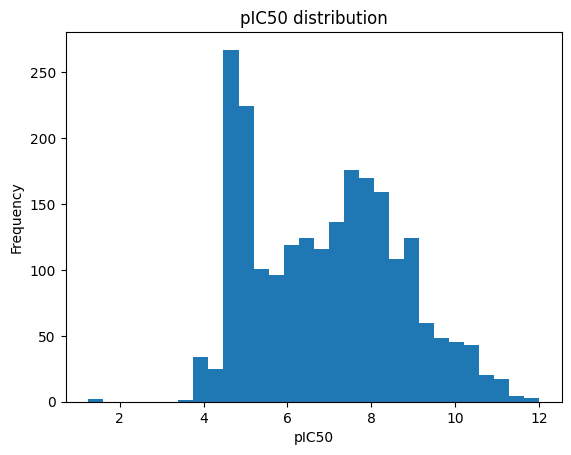

In [24]:
plt.hist(y_mlp, bins=30)
plt.title("pIC50 distribution")
plt.xlabel("pIC50")
plt.ylabel("Frequency")
plt.show()

In [25]:
# Save as parquet 
fp_col_names = [f'fp_{i}' for i in range(2048)]
feature_cols = fp_col_names + physchem_cols

df_mlp_out = pd.DataFrame(X_mlp, columns=feature_cols)
df_mlp_out.insert(0, 'canonical_smiles', df_mlp['canonical_smiles'].values)
df_mlp_out.insert(1, 'pic50', y_mlp)
df_mlp_out.insert(2, 'n_measurements', df_mlp['n_measurements'].values)
df_mlp_out.insert(3, 'mol_id', df_mlp['mol_id'].values)

df_mlp_out.to_parquet(MLP_PARQUET, index=False)
print(f'Saved MLP features: {MLP_PARQUET} ({df_mlp_out.shape})')

Saved MLP features: data\mlp_features_2147_mlp.parquet ((2222, 2060))


### 1.3 GNN features - atom & bond graphs

Each molecule becomes a `torch_geometric.data.Data` object with:
- `x`: node (atom) feature matrix
- `edge_index`: bidirectional COO adjacency
- `edge_attr`: bond feature matrix
- `y`: pic50 scalar
- `smiles`: original canonical SMILES for reference

In [26]:
ATOMS = ['C', 'N', 'O', 'S', 'F', 'Cl', 'Br', 'I', 'P', 'Se', 'Si', 'B', 'unknown']

HYBRIDIZATION_TYPES = [
    Chem.rdchem.HybridizationType.S,
    Chem.rdchem.HybridizationType.SP,
    Chem.rdchem.HybridizationType.SP2,
    Chem.rdchem.HybridizationType.SP3,
    Chem.rdchem.HybridizationType.SP3D,
    Chem.rdchem.HybridizationType.SP3D2,
    Chem.rdchem.HybridizationType.OTHER, # fallback
]

CHIRAL_TYPES = [
    Chem.rdchem.ChiralType.CHI_UNSPECIFIED,
    Chem.rdchem.ChiralType.CHI_TETRAHEDRAL_CW,
    Chem.rdchem.ChiralType.CHI_TETRAHEDRAL_CCW,
    Chem.rdchem.ChiralType.CHI_OTHER,
]

BOND_TYPES = [
    Chem.rdchem.BondType.SINGLE,
    Chem.rdchem.BondType.DOUBLE,
    Chem.rdchem.BondType.TRIPLE,
    Chem.rdchem.BondType.AROMATIC,
]

BOND_STEREO = [
    Chem.rdchem.BondStereo.STEREONONE,
    Chem.rdchem.BondStereo.STEREOE,
    Chem.rdchem.BondStereo.STEREOZ,
    Chem.rdchem.BondStereo.STEREOANY,
]

def one_hot(value, vocab: list) -> list[int]:
    vec = [0] * len(vocab)
    vec[vocab.index(value) if value in vocab else -1] = 1
    return vec

def safe_norm(value: float, max_val: float) -> float: #clamp01
    return min(float(value), max_val) / max_val

def atom_features(atom, ring_info) -> list[float]:
    symbol = atom.GetSymbol()
    idx = atom.GetIdx()

    # Smallest ring size
    smallest_ring = 0
    if ring_info is not None:
        for ring in ring_info.AtomRings():
            if idx in ring:
                size = len(ring)
                smallest_ring = size if smallest_ring == 0 else min(smallest_ring, size)

    # Gasteiger charge
    try:
        g = float(atom.GetDoubleProp('_GasteigerCharge'))
        if np.isnan(g):
            g = 0.0
        g = np.clip(g, -1.0, 1.0)
    except:
        g = 0.0

    return [
        *one_hot(symbol, ATOMS), # 12 elements
        safe_norm(atom.GetAtomicNum(), 53.0),  # 1 atomic number
        safe_norm(atom.GetDegree(), 6.0), # 1 number of explicit neighbors
        safe_norm(atom.GetTotalValence(), 6.0), # 1 total valence
        atom.GetFormalCharge() / 4.0, 
        safe_norm(atom.GetTotalNumHs(), 4.0), # 1 total number of hydrogens
        int(atom.IsInRing()),
        int(atom.IsInRingSize(5)),
        int(atom.IsInRingSize(6)),
        int(atom.GetIsAromatic()),
        *one_hot(atom.GetHybridization(), HYBRIDIZATION_TYPES),
        *one_hot(atom.GetChiralTag(), CHIRAL_TYPES),
        g,
        safe_norm(min(smallest_ring, 12), 12.0),
    ]

def bond_features(bond) -> list[float]:
    return [
        *one_hot(bond.GetBondType(), BOND_TYPES),
        *one_hot(bond.GetStereo(), BOND_STEREO),
        int(bond.IsInRing()),
        int(bond.GetIsConjugated()),
        int(bond.GetIsAromatic()),
    ]

In [27]:
def get_atom_feature_dim() -> int:
    mol = Chem.MolFromSmiles("CC")
    rdPartialCharges.ComputeGasteigerCharges(mol)
    ring_info = mol.GetRingInfo()
    return len(atom_features(next(mol.GetAtoms()), ring_info))

def get_edge_feature_dim() -> int:
    mol = Chem.MolFromSmiles("CC")
    return len(bond_features(mol.GetBondBetweenAtoms(0, 1)))

physchem_cols = [
    'mw_freebase',
    'alogp',
    'hba',
    'hbd',
    'psa',
    'rtb',
    'aromatic_rings',
    'qed_weighted'
]

NODE_DIM = get_atom_feature_dim()
EDGE_DIM = get_edge_feature_dim()
PHYS_DIM = len(physchem_cols)

print(
    f"Node feature dim: {NODE_DIM}, "
    f"Edge feature dim: {EDGE_DIM}, "
    f"Physchem dim: {PHYS_DIM}"
)

Node feature dim: 35, Edge feature dim: 11, Physchem dim: 8


In [28]:
def smiles_to_graph(smi: str, y_val: float, phys_vec: np.ndarray | None = None) -> Data | None:
    """
    Convert a SMILES string to a PyG Data object.

    Args:
        smi:      canonical SMILES string
        y_val:    target pIC50 value
        phys_vec: optional (PHYS_DIM,) physicochemical descriptor vector;
                  stored as graph-level attribute `phys` and concatenated
                  at readout in the GNN+physchem mixed model

    Returns:
        PyG Data object, or None if the molecule couldn't be parsed.
    """

    mol = Chem.MolFromSmiles(smi)
    if mol is None or mol.GetNumAtoms() == 0:
        return None

    # Compute Gasteiger charges (needed by extended atom_features)
    try:
        rdPartialCharges.ComputeGasteigerCharges(mol)
    except Exception:
        pass   # fallback: charges stay 0 in atom_features

    ring_info = mol.GetRingInfo()

    # Node features
    node_feats = torch.tensor(
        [atom_features(a, ring_info) for a in mol.GetAtoms()],
        dtype=torch.float,
    )  # shape: (num_atoms, NODE_DIM)

    # Bidirectional edges
    src, dst, edge_feats = [], [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        feats = bond_features(bond)
        src += [i, j]
        dst += [j, i]
        edge_feats += [feats, feats]

    if len(src) == 0:
        src, dst = [0], [0]
        edge_feats = [[0.0] * EDGE_DIM]

    edge_index = torch.tensor([src, dst], dtype=torch.long)
    edge_attr = torch.tensor(edge_feats, dtype=torch.float)

    # Physicochemical graph-level features
    if phys_vec is None:
        phys_vec = np.zeros(PHYS_DIM, dtype=np.float32)
    phys_tensor = torch.tensor(phys_vec, dtype=torch.float).unsqueeze(0) # (1, PHYS_DIM)

    return Data(
        x = node_feats,
        edge_index = edge_index,
        edge_attr = edge_attr,
        y = torch.tensor([y_val], dtype=torch.float),
        phys = phys_tensor,
        smiles = smi,
    )

# Build phys matrix aligned to df_mlp
phys_matrix = df_mlp[physchem_cols].values.astype(np.float32)

col_medians = np.nanmedian(phys_matrix, axis=0)
nan_mask = np.isnan(phys_matrix)
phys_matrix[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])

# Normalise physicochemical features
_phys_scaler_global = StandardScaler().fit(phys_matrix)
phys_matrix_norm = _phys_scaler_global.transform(phys_matrix)

graph_list = []
graph_mol_ids = []

for i, row in df_mlp.iterrows():
    smi = row["canonical_smiles"]
    pic50 = row["pic50"]
    mol_id = row["mol_id"]

    g = smiles_to_graph(smi, float(pic50), phys_matrix_norm[i])

    if g is not None:
        graph_list.append(g)
        graph_mol_ids.append(mol_id)

print(f"Graphs built: {len(graph_list)}")


Graphs built: 2222


In [29]:
torch.save(graph_list, GNN_PT)
print(f'Saved GNN graphs: {GNN_PT}')

graphs_check = torch.load(GNN_PT, weights_only=False)
num_nodes_list = [g.num_nodes for g in graphs_check]
print(f'Reloaded {len(graphs_check)} graphs')
print(f'Atoms per molecule — mean: {np.mean(num_nodes_list):.1f}, '
      f'min: {np.min(num_nodes_list)}, max: {np.max(num_nodes_list)}')
print(f'Node feature dim: {graphs_check[0].x.shape[1]}  (expected {NODE_DIM})')
print(f'Edge feature dim: {graphs_check[0].edge_attr.shape[1]}  (expected {EDGE_DIM})')
print(f'Physchem dim:     {graphs_check[0].phys.shape[1]}  (expected {PHYS_DIM})')


Saved GNN graphs: data\gnn_graphs_2147_gnn.pt
Reloaded 2222 graphs
Atoms per molecule — mean: 27.9, min: 12, max: 73
Node feature dim: 35  (expected 35)
Edge feature dim: 11  (expected 11)
Physchem dim:     8  (expected 8)


# Part 2 — Splitting

Split both MLP and GNN datasets with Scaffold split 3 ways:
- Standard Bemis-Murcko scaffold split
- Randomized scaffold split - computes scaaffold, shiffles groups randomly and then assigns eo train/val/test sets

Splits are 0.8 / 0.1 / 0.1

In [ ]:
# Load prepared data 
df_mlp_feat = pd.read_parquet(MLP_PARQUET)
gnn_graphs = torch.load(GNN_PT, weights_only=False)

# Make sure both share the same SMILES
assert len(df_mlp_feat) == len(gnn_graphs)
for i in range(len(df_mlp_feat)):
    assert df_mlp_feat.iloc[i]["canonical_smiles"] == gnn_graphs[i].smiles

smiles_list = df_mlp_feat['canonical_smiles'].tolist()
N = len(smiles_list)
print(f'Total compounds: {N}')

VAL_FRAC  = 0.10
TEST_FRAC = 0.10

SPLIT_DIR = DATA_DIR / 'splits_experiment'
SPLIT_DIR.mkdir(exist_ok=True)

Total compounds: 2222


In [31]:
def get_scaffold(smi: str) -> str:
    """
    Compute Bemis-Murcko scaffold SMILES.
    Falls back to the full canonical SMILES for acyclic molecules (no rings → empty scaffold).
    """
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return smi
    scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
    return scaffold if scaffold else smi

### 2.1 Scaffold split - standard Bemis-Murcko

In [32]:
scaffold_to_indices = defaultdict(list)
for idx, smi in enumerate(smiles_list):
    scaffold_to_indices[get_scaffold(smi)].append(idx)

# sort scaffolds by size (standard)
scaffold_sets = sorted(scaffold_to_indices.values(), key=len, reverse=True)

target_test = int(N * TEST_FRAC)
target_val  = int(N * VAL_FRAC)

sc_train, sc_val, sc_test = [], [], []
counts = {'train': 0, 'val': 0, 'test': 0}

for group in scaffold_sets:
    if counts['test'] < target_test:
        sc_test.extend(group)
        counts['test'] += len(group)
    elif counts['val'] < target_val:
        sc_val.extend(group)
        counts['val'] += len(group)
    else:
        sc_train.extend(group)
        counts['train'] += len(group)

scaffold_split = {
    'train': np.array(sc_train),
    'val': np.array(sc_val),
    'test': np.array(sc_test),
}

for split_name, idx in scaffold_split.items():
    np.save(SPLIT_DIR / f'scaffold_{split_name}.npy', idx)

print("Standard scaffold split:")
print(f"train: {len(sc_train)}, val: {len(sc_val)}, test: {len(sc_test)}")

Standard scaffold split:
train: 1769, val: 229, test: 224


### 2.2 Scaffold split - with randomized ordering

In [33]:
rng = np.random.default_rng(SEED)
scaffold_sets_rand = scaffold_sets.copy()
rng.shuffle(scaffold_sets_rand)

sc_train, sc_val, sc_test = [], [], []
counts = {'train': 0, 'val': 0, 'test': 0}

for group in scaffold_sets_rand:
    if counts['test'] < target_test:
        sc_test.extend(group)
        counts['test'] += len(group)
    elif counts['val'] < target_val:
        sc_val.extend(group)
        counts['val'] += len(group)
    else:
        sc_train.extend(group)
        counts['train'] += len(group)

rand_scaffold_split = {
    'train': np.array(sc_train),
    'val': np.array(sc_val),
    'test': np.array(sc_test),
}

for split_name, idx in rand_scaffold_split.items():
    np.save(SPLIT_DIR / f'scaffold_random_{split_name}.npy', idx)

print("Randomized scaffold split:")
print(f"train: {len(sc_train)}, val: {len(sc_val)}, test: {len(sc_test)}")

Randomized scaffold split:
train: 1762, val: 237, test: 223


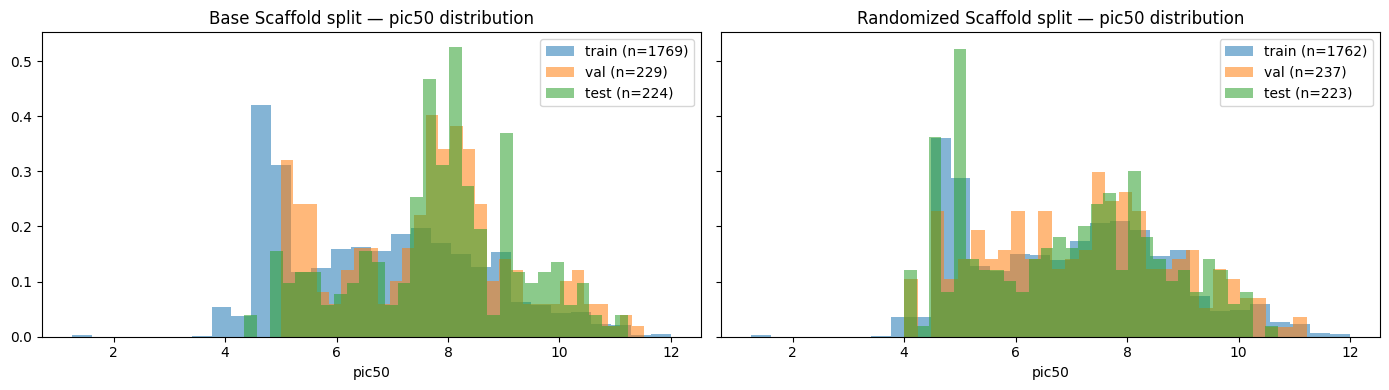

In [ ]:
# Visualise pic50 distributions across splits to check for label shift
y_all = df_mlp_feat['pic50'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, (split_type, split_dict) in zip(axes, [
    ('Base Scaffold', scaffold_split),
    ('Randomized Scaffold', rand_scaffold_split),
]):
    for name, idx in split_dict.items():
        ax.hist(y_all[idx], bins=30, alpha=0.55, label=f'{name} (n={len(idx)})', density=True)
    ax.set_title(f'{split_type} split — pic50 distribution')
    ax.set_xlabel('pic50')
    ax.legend()

plt.tight_layout()
plt.show()

---
# Part 3 — Model Experimentation

All experiments are tracked with **MLflow**. For each run:
- hyperparameters are logged as params
- per-epoch train/val loss is logged as metrics
- final test RMSE and R² are logged
- the best model checkpoint is saved as an artefact

Run `mlflow ui` in your terminal after to explore results.

In [36]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Shared training helpers
def evaluate_regression(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "rmse": np.sqrt(mse),
        "r2": r2_score(y_true, y_pred),
        "mae": np.mean(np.abs(y_true - y_pred)),
    }

def early_stop_check(val_losses: list[float], patience: int = 20) -> bool:
    """Return True if val loss hasn't improved in `patience` epochs."""
    if len(val_losses) <= patience:
        return False
    return min(val_losses[:-patience]) <= min(val_losses[-patience:])

print('Helpers defined.')

Device: cuda
Helpers defined.


## 3.1 - MLP Experiments

In [37]:
def load_mlp_split(split_type: str):
    feature_cols = [c for c in df_mlp_feat.columns
                    if c not in ('canonical_smiles', 'pic50', 'n_measurements')]
    X = df_mlp_feat[feature_cols].values.astype(np.float32)
    y = df_mlp_feat['pic50'].values.astype(np.float32)

    tr_idx  = np.load(SPLIT_DIR / f'{split_type}_train.npy')
    val_idx = np.load(SPLIT_DIR / f'{split_type}_val.npy')
    te_idx  = np.load(SPLIT_DIR / f'{split_type}_test.npy')

    fp_bits = 2048
    scaler  = StandardScaler()
    X[tr_idx, fp_bits:] = scaler.fit_transform(X[tr_idx,  fp_bits:])
    X[val_idx, fp_bits:] = scaler.transform(X[val_idx, fp_bits:])
    X[te_idx, fp_bits:] = scaler.transform(X[te_idx,  fp_bits:])

    to_t = lambda idx: (
        torch.tensor(X[idx], dtype=torch.float32),
        torch.tensor(y[idx], dtype=torch.float32).unsqueeze(1),
    )
    return (*to_t(tr_idx), *to_t(val_idx), *to_t(te_idx), scaler)

In [45]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dims: list[int],
        dropout: float = 0.3,
        use_batchnorm: bool = True,
        activation: str = 'relu',
    ):
        super().__init__()
        act_fn = {'relu': nn.ReLU, 'gelu': nn.GELU, 'silu': nn.SiLU}[activation]

        layers = []
        in_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h_dim))
            layers.append(act_fn())
            layers.append(nn.Dropout(dropout))
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_mlp(
    config: dict,
    split_type: str,
    experiment_name: str = 'MLP_experiments',
) -> dict:
    """
    Train one MLP config, log everything to MLflow, return test metrics.
    """
    X_tr, y_tr, X_val, y_val, X_te, y_te, _ = load_mlp_split(split_type)

    train_loader = DataLoader(
        TensorDataset(X_tr, y_tr),
        batch_size=config['batch_size'], shuffle=True,
    )
    val_loader = DataLoader(
        TensorDataset(X_val, y_val),
        batch_size=256, shuffle=False,
    )

    model = MLP(
        input_dim     = X_tr.shape[1],
        hidden_dims   = config['hidden_dims'],
        dropout       = config['dropout'],
        use_batchnorm = config.get('batchnorm', True),
        activation    = config.get('activation', 'relu'),
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config.get('wd', 1e-5))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    loss_fn   = nn.HuberLoss(delta=1.0)

    mlflow.set_experiment(experiment_name)
    run_name = f"mlp_{split_type}_{'_'.join(map(str, config['hidden_dims']))}_{config['dropout']}"

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({**config, 'split': split_type, 'model_type': 'MLP'})

        best_val_loss = float('inf')
        best_state    = None
        val_losses    = []
        patience      = config.get('patience', 30)

        for epoch in range(1, config['epochs'] + 1):
            # Train
            model.train()
            train_loss = 0.0
            for xb, yb in train_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                optimizer.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                optimizer.step()
                train_loss += loss.item() * len(xb)
            train_loss /= len(train_loader.dataset)

            # Validate
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                    val_loss += loss_fn(model(xb), yb).item() * len(xb)
            val_loss /= len(val_loader.dataset)
            val_losses.append(val_loss)
            scheduler.step(val_loss)

            mlflow.log_metrics({'train_loss': train_loss, 'val_loss': val_loss}, step=epoch)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state    = copy.deepcopy(model.state_dict())

            if early_stop_check(val_losses, patience):
                print(f'  Early stop at epoch {epoch}')
                break

        # Test evaluation with best weights
        model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            y_pred = model(X_te.to(DEVICE)).cpu().numpy().flatten()
        y_true = y_te.numpy().flatten()

        metrics = evaluate_regression(y_true, y_pred)
        mlflow.log_metrics({f'test_{k}': v for k, v in metrics.items()})
        
        model.eval()
        mlflow.pytorch.log_model(model, name="model")

        print(f'  [{run_name}]  RMSE={metrics["rmse"]:.3f}  R²={metrics["r2"]:.3f}')
        return metrics

In [46]:
# MLP experiment grid
# Each config is one MLflow run, tried on both split types

mlp_configs = [
    # Baseline — shallow
    dict(hidden_dims=[512, 256], dropout=0.3, lr=1e-3, batch_size=64, epochs=200, patience=30, name='shallow'),
    # Deeper
    dict(hidden_dims=[1024, 512, 256], dropout=0.3, lr=1e-3, batch_size=64, epochs=200, patience=30, name='deep_3'),
    dict(hidden_dims=[1024, 512, 256, 128], dropout=0.3, lr=1e-3, batch_size=64, epochs=200, patience=30, name='deep_4'),
    # Higher dropout — more regularisation for small data
    dict(hidden_dims=[1024, 512, 256], dropout=0.5, lr=1e-3, batch_size=64, epochs=200, patience=30, name='deep_high_drop'),
    # GELU activation
    dict(hidden_dims=[1024, 512, 256], dropout=0.3, lr=1e-3, batch_size=64, epochs=200, patience=30, activation='gelu', name='gelu'),
    # No batchnorm
    dict(hidden_dims=[1024, 512, 256], dropout=0.3, lr=1e-3, batch_size=64, epochs=200, patience=30, batchnorm=False, name='no_bn'),
    # Smaller LR
    dict(hidden_dims=[1024, 512, 256], dropout=0.3, lr=3e-4, batch_size=64, epochs=300, patience=40, name='low_lr'),
]

mlp_results = []
for cfg in mlp_configs:
    for split in ['scaffold', 'scaffold_random']:
        print(f'\nRunning MLP [{cfg["name"]}] | split={split}')
        metrics = train_mlp(cfg, split_type=split, experiment_name='MLP_experiments')
        mlp_results.append({'config': cfg['name'], 'split': split, **metrics})

pd.DataFrame(mlp_results).sort_values('rmse')


Running MLP [shallow] | split=scaffold


2026/06/09 20:20:09 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/09 20:20:09 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


  Early stop at epoch 129


2026/06/09 20:20:13 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


  [mlp_scaffold_512_256_0.3]  RMSE=0.620  R²=0.817

Running MLP [shallow] | split=scaffold_random


...

2026/06/09 20:23:17 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/09 20:23:17 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


  Early stop at epoch 115


2026/06/09 20:23:21 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


  [mlp_scaffold_random_1024_512_256_0.3]  RMSE=0.832  R²=0.761


,config,split,rmse,r2,mae
0,shallow,scaffold,0.619706,0.816585,0.464577
4,deep_4,scaffold,0.628030,0.811624,0.488008
6,deep_high_drop,scaffold,0.636014,0.806804,0.490927
2,deep_3,scaffold,0.646063,0.800651,0.501006
8,gelu,scaffold,0.655663,0.794683,0.502146
12,low_lr,scaffold,0.665307,0.788598,0.506374
10,no_bn,scaffold,0.721342,0.751489,0.559729
13,low_lr,scaffold_random,0.831821,0.760798,0.622577
9,gelu,scaffold_random,0.849113,0.750750,0.661669
5,deep_4,scaffold_random,0.855155,0.747190,0.648368


In [ ]:
# Try different dropouts for shallow model

mlp_configs = [
    # Baseline — shallow
    dict(hidden_dims=[512, 256], dropout=0.3, lr=1e-3, batch_size=64, epochs=200, patience=30, name='shallow'),
    # Lower dropout — more regularisation for small data
    dict(hidden_dims=[512, 256], dropout=0.2, lr=1e-3, batch_size=64, epochs=200, patience=30, name='dropout_02'),
    dict(hidden_dims=[512, 256], dropout=0.15, lr=1e-3, batch_size=64, epochs=200, patience=30, name='dropout_015'),
    dict(hidden_dims=[512, 256], dropout=0.1, lr=1e-3, batch_size=64, epochs=200, patience=30, name='dropout_01'),
]

mlp_results = []
for cfg in mlp_configs:
    for split in ['scaffold', 'scaffold_random']:
        print(f'\nRunning MLP [{cfg["name"]}] | split={split}')
        metrics = train_mlp(cfg, split_type=split, experiment_name='MLP_experiments')
        mlp_results.append({'config': cfg['name'], 'split': split, **metrics})

pd.DataFrame(mlp_results).sort_values('rmse')


Running MLP [shallow] | split=scaffold


2026/06/09 20:44:11 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/09 20:44:11 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


  Early stop at epoch 109


2026/06/09 20:44:15 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


  [mlp_scaffold_512_256_0.3]  RMSE=0.649  R²=0.799

Running MLP [shallow] | split=scaffold_random


...

2026/06/09 20:45:45 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/09 20:45:45 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


  Early stop at epoch 135


2026/06/09 20:45:49 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


  [mlp_scaffold_random_512_256_0.1]  RMSE=0.869  R²=0.739


,config,split,rmse,r2,mae
2,dropout_02,scaffold,0.622065,0.815185,0.468231
6,dropout_01,scaffold,0.630605,0.810076,0.478048
4,dropout_015,scaffold,0.644096,0.801863,0.482082
0,shallow,scaffold,0.648651,0.799051,0.510696
1,shallow,scaffold_random,0.868980,0.738950,0.666784
7,dropout_01,scaffold_random,0.869324,0.738743,0.681440
3,dropout_02,scaffold_random,0.890131,0.726087,0.709437
5,dropout_015,scaffold_random,0.890636,0.725776,0.689566


In [50]:
# Run chosen model 3 times to check:

mlp_configs = [
    dict(hidden_dims=[512, 256], dropout=0.2, lr=1e-3, batch_size=64, epochs=200, patience=30, name='dropout_02'),
    dict(hidden_dims=[512, 256], dropout=0.2, lr=1e-3, batch_size=64, epochs=200, patience=30, name='dropout_02'),
    dict(hidden_dims=[512, 256], dropout=0.2, lr=1e-3, batch_size=64, epochs=200, patience=30, name='dropout_02'),
]

mlp_results = []
for cfg in mlp_configs:
    for split in ['scaffold']:
        print(f'\nRunning MLP [{cfg["name"]}] | split={split}')
        metrics = train_mlp(cfg, split_type=split, experiment_name='MLP_experiments')
        mlp_results.append({'config': cfg['name'], 'split': split, **metrics})

pd.DataFrame(mlp_results).sort_values('rmse')


Running MLP [dropout_02] | split=scaffold


2026/06/09 20:49:24 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/09 20:49:24 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


  Early stop at epoch 99


2026/06/09 20:49:28 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


  [mlp_scaffold_512_256_0.2]  RMSE=0.652  R²=0.797

Running MLP [dropout_02] | split=scaffold


...

2026/06/09 20:49:47 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/09 20:49:47 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


  Early stop at epoch 81


2026/06/09 20:49:51 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


  [mlp_scaffold_512_256_0.2]  RMSE=0.614  R²=0.820


,config,split,rmse,r2,mae
2,dropout_02,scaffold,0.614234,0.819809,0.459228
1,dropout_02,scaffold,0.636451,0.806539,0.486794
0,dropout_02,scaffold,0.652223,0.796832,0.493531


## 3.2 - GNN Experiments

In [51]:
# GNN dataset helpers

def load_gnn_split(split_type: str):
    graphs = torch.load(GNN_PT, weights_only=False)

    tr_idx = np.load(SPLIT_DIR / f'{split_type}_train.npy')
    val_idx = np.load(SPLIT_DIR / f'{split_type}_val.npy')
    te_idx = np.load(SPLIT_DIR / f'{split_type}_test.npy')

    def select(idx):
        return [graphs[i] for i in idx]

    return select(tr_idx), select(val_idx), select(te_idx)


## 3B — GNN Experiments (Enhanced)

### What changed vs baseline:
- **Richer featurisation** (30-dim atom, 10-dim bond) including Gasteiger charges, chirality, stereo
- **Physicochemical features** attached as graph-level attributes (`phys`) — injected at readout in mixed models
- **Residual GINE** — skip connections in every conv layer to ease gradient flow
- **Mixed GNN+Physchem model** — fuses graph readout with the 8 ChEMBL physchem descriptors before the regression head
- **Experiment configs** cover: baseline, residual, mixed, AttentiveFP variants, and combinations


In [55]:
class GNNRegressor(nn.Module):

    def __init__(
        self,
        node_dim:    int,
        edge_dim:    int,
        hidden_dim:  int   = 256,
        n_layers:    int   = 4,
        dropout:     float = 0.2,
        pooling:     str   = 'mean',
    ):
        super().__init__()
        assert pooling in {'mean', 'add'}, "pooling must be 'mean' or 'add'"
        self.pooling = pooling
        self.dropout_p = dropout

        self.node_proj = nn.Linear(node_dim, hidden_dim)

        # Projects raw bond features into hidden_dim space before message passing
        self.edge_encoder = nn.Sequential(
            nn.Linear(edge_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(n_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
            )
            self.convs.append(GINEConv(mlp, edge_dim=hidden_dim))
            self.norms.append(nn.BatchNorm1d(hidden_dim))

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = (
            data.x, data.edge_index, data.edge_attr, data.batch
        )
        x         = self.node_proj(x)
        edge_attr = self.edge_encoder(edge_attr)   # ← key difference

        for conv, norm in zip(self.convs, self.norms):
            residual = x
            x = conv(x, edge_index, edge_attr)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout_p, training=self.training)
            x = x + residual                       # residual skip

        if self.pooling == 'add':
            x = global_add_pool(x, batch)
        else:
            x = global_mean_pool(x, batch)

        return self.head(x)

class GINEModel(nn.Module):
    def __init__(
        self,
        node_dim: int,
        edge_dim: int,
        hidden_dim: int = 256,
        num_layers: int = 4,
        dropout: float = 0.2,
    ):
        super().__init__()

        self.node_encoder = nn.Linear(node_dim, hidden_dim)
        self.edge_encoder = nn.Linear(edge_dim, hidden_dim)

        self.num_layers = num_layers

        self.convs = nn.ModuleList()
        self.batch_norms = nn.ModuleList()

        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, 2 * hidden_dim),
                nn.ReLU(),
                nn.Linear(2 * hidden_dim, hidden_dim),
            )

            self.convs.append(
                GINEConv(mlp, edge_dim=hidden_dim, train_eps=True)
            )
            self.batch_norms.append(nn.BatchNorm1d(hidden_dim))

        self.pool = global_mean_pool

        self.graph_head = nn.Sequential(
            nn.Linear(hidden_dim * num_layers, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = (
            data.x, data.edge_index, data.edge_attr, data.batch
        )

        x = self.node_encoder(x)
        edge_attr = self.edge_encoder(edge_attr)

        layer_outputs = []

        for conv, bn in zip(self.convs, self.batch_norms):
            x = conv(x, edge_index, edge_attr)
            x = bn(x)
            x = F.relu(x)

            layer_outputs.append(self.pool(x, batch))

        x = torch.cat(layer_outputs, dim=1)
        return self.graph_head(x)

In [56]:
def train_gnn(
    config: dict,
    split_type: str,
    experiment_name: str = "GNN_experiments",
) -> dict:

    tr_graphs, val_graphs, te_graphs = load_gnn_split(split_type)

    train_loader = GeoDataLoader(tr_graphs, batch_size=config["batch_size"], shuffle=True)
    val_loader   = GeoDataLoader(val_graphs, batch_size=128, shuffle=False)
    test_loader  = GeoDataLoader(te_graphs, batch_size=128, shuffle=False)

    model_type = config["model_type"]

    # ─────────────────────────────────────────────
    # Model selection (NEW ARCH ONLY)
    # ─────────────────────────────────────────────
    if model_type == "gner":
        model = GNNRegressor(
            node_dim=NODE_DIM,
            edge_dim=EDGE_DIM,
            hidden_dim=config["hidden_dim"],
            n_layers=config["n_layers"],
            dropout=config["dropout"],
            pooling=config.get("pooling", "mean"),
        )

    elif model_type == "gine":
        model = GINEModel(
            node_dim=NODE_DIM,
            edge_dim=EDGE_DIM,
            hidden_dim=config["hidden_dim"],
            num_layers=config["n_layers"],
            dropout=config["dropout"],
        )

    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    model = model.to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config.get("wd", 1e-4),
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=config["epochs"],
        eta_min=config["lr"] * 0.01,
    )

    loss_fn = nn.HuberLoss(delta=1.0)

    # ─────────────────────────────────────────────
    # Logging (aligned with new pooling semantics)
    # ─────────────────────────────────────────────
    pooling_tag = (
        "singlepool" if model_type == "gner"
        else "jkpool"
    )

    run_name = (
        f"{model_type}_{pooling_tag}_{split_type}_"
        f"{config['hidden_dim']}h_{config['n_layers']}l"
    )

    mlflow.set_experiment(experiment_name)

    with mlflow.start_run(run_name=run_name):

        mlflow.log_params({**config, "split": split_type})

        best_val_loss = float("inf")
        best_state = None
        val_losses = []
        patience = config.get("patience", 30)

        # ─────────────────────────────
        # Training loop
        # ─────────────────────────────
        for epoch in range(1, config["epochs"] + 1):

            model.train()
            train_loss = 0.0

            for batch in train_loader:
                batch = batch.to(DEVICE)

                optimizer.zero_grad()
                pred = model(batch)

                loss = loss_fn(pred, batch.y.unsqueeze(1))
                loss.backward()

                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

                train_loss += loss.item() * batch.num_graphs

            train_loss /= len(tr_graphs)
            scheduler.step()

            # ─────────────────────────────
            # Validation
            # ─────────────────────────────
            model.eval()
            val_loss = 0.0

            with torch.no_grad():
                for batch in val_loader:
                    batch = batch.to(DEVICE)
                    val_loss += loss_fn(
                        model(batch),
                        batch.y.unsqueeze(1)
                    ).item() * batch.num_graphs

            val_loss /= len(val_graphs)
            val_losses.append(val_loss)

            mlflow.log_metrics(
                {"train_loss": train_loss, "val_loss": val_loss},
                step=epoch,
            )

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = copy.deepcopy(model.state_dict())

            if early_stop_check(val_losses, patience):
                break

        # ─────────────────────────────
        # Test evaluation
        # ─────────────────────────────
        model.load_state_dict(best_state)
        model.eval()

        y_preds, y_trues = [], []

        with torch.no_grad():
            for batch in test_loader:
                batch = batch.to(DEVICE)
                y_preds.append(model(batch).cpu().numpy().ravel())
                y_trues.append(batch.y.cpu().numpy().ravel())

        y_pred = np.concatenate(y_preds)
        y_true = np.concatenate(y_trues)

        metrics = evaluate_regression(y_true, y_pred)

        mlflow.log_metrics({f"test_{k}": v for k, v in metrics.items()})
        mlflow.pytorch.log_model(model, name="model")

        print(f"[{run_name}] RMSE={metrics['rmse']:.3f} R2={metrics['r2']:.3f}")

        return metrics

In [ ]:
gnn_configs = [

    # ─────────────────────────────────────────────
    # GNNRegressor (baseline + regularization sweep)
    # ─────────────────────────────────────────────

    dict(
        model_type="gner",
        hidden_dim=128,
        n_layers=4,
        dropout=0.15,
        pooling="mean",
        lr=3e-4,
        batch_size=64,
        epochs=250,
        patience=35,
        name="gner_128_4l_mean",
    ),

    dict(
        model_type="gner",
        hidden_dim=256,
        n_layers=4,
        dropout=0.15,
        pooling="mean",
        lr=3e-4,
        batch_size=64,
        epochs=250,
        patience=35,
        name="gner_256_4l_mean",
    ),

    dict(
        model_type="gner",
        hidden_dim=128,
        n_layers=4,
        dropout=0.15,
        pooling="add",
        lr=3e-4,
        batch_size=64,
        epochs=250,
        patience=35,
        name="gner_128_4l_add",
    ),

    dict(
        model_type="gner",
        hidden_dim=128,
        n_layers=6,
        dropout=0.15,
        pooling="mean",
        lr=3e-4,
        batch_size=64,
        epochs=300,
        patience=40,
        name="gner_128_6l_mean",
    ),

    dict(
        model_type="gner",
        hidden_dim=128,
        n_layers=4,
        dropout=0.25,
        pooling="mean",
        lr=1e-3,
        batch_size=64,
        epochs=250,
        patience=35,
        name="gner_128_4l_drop25",
    ),

         # ─────────────────────────────────────────────
    # GINE baselines (JK pooling, graph-only)
    # ─────────────────────────────────────────────

    dict(
        model_type="gine",
        use_physchem=False,
        use_residual=True,
        hidden_dim=256,
        n_layers=4,
        dropout=0.3,
        lr=1e-3,
        batch_size=32,
        epochs=250,
        patience=35,
        readout_mlp=[512, 256],
        name="gine_res_256_4l",
    ),

    dict(
        model_type="gine",
        use_physchem=False,
        use_residual=True,
        hidden_dim=512,
        n_layers=4,
        dropout=0.3,
        lr=1e-3,
        batch_size=32,
        epochs=250,
        patience=35,
        readout_mlp=[512, 256],
        name="gine_res_512_4l",
    ),

    dict(
        model_type="gine",
        use_physchem=False,
        use_residual=False,
        hidden_dim=256,
        n_layers=4,
        dropout=0.3,
        lr=1e-3,
        batch_size=32,
        epochs=250,
        patience=35,
        readout_mlp=[512, 256],
        name="gine_nores_256_4l",
    ),

        # ─────────────────────────────────────────────
    # GINE + physicochemical fusion
    # ─────────────────────────────────────────────

    dict(
        model_type="gine",
        use_physchem=True,
        use_residual=True,
        hidden_dim=256,
        n_layers=4,
        dropout=0.3,
        lr=1e-3,
        batch_size=32,
        epochs=250,
        patience=35,
        readout_mlp=[512, 256],
        name="gine_mixed_256_4l",
    ),

    dict(
        model_type="gine",
        use_physchem=True,
        use_residual=True,
        hidden_dim=512,
        n_layers=4,
        dropout=0.3,
        lr=1e-3,
        batch_size=32,
        epochs=250,
        patience=35,
        readout_mlp=[512, 256],
        name="gine_mixed_512_4l",
    ),

    dict(
        model_type="gine",
        use_physchem=True,
        use_residual=True,
        hidden_dim=256,
        n_layers=6,
        dropout=0.3,
        lr=5e-4,
        batch_size=32,
        epochs=300,
        patience=40,
        readout_mlp=[512, 256],
        name="gine_mixed_256_6l",
    ),

    dict(
        model_type="gine",
        use_physchem=True,
        use_residual=True,
        hidden_dim=256,
        n_layers=4,
        dropout=0.5,
        lr=1e-3,
        batch_size=32,
        epochs=300,
        patience=40,
        readout_mlp=[512, 256],
        name="gine_mixed_256_4l_drop50",
    ),

    dict(
        model_type="gine",
        use_physchem=True,
        use_residual=True,
        hidden_dim=256,
        n_layers=4,
        dropout=0.3,
        lr=3e-4,
        batch_size=32,
        epochs=350,
        patience=50,
        readout_mlp=[512, 256],
        name="gine_mixed_256_4l_lowlr",
    )
]
     

# Run scaffold split for all configs; run random too for the mixed ones
gnn_results = []
for cfg in gnn_configs:
    splits_to_run = ['scaffold']
    for split in splits_to_run:
        print(f'\nRunning GNN [{cfg["name"]}] | split={split}')
        metrics = train_gnn(cfg, split_type=split, experiment_name='GNN_experiments')
        gnn_results.append({'model': cfg['name'], 'split': split, **metrics})

df_gnn_res = pd.DataFrame(gnn_results)
print('\n=== GNN Results (scaffold sorted by R²) ===')
print(df_gnn_res[df_gnn_res['split']=='scaffold'].sort_values('r2', ascending=False).to_string(index=False))



Running GNN [gner_128_4l_mean] | split=scaffold


2026/06/09 22:28:34 INFO mlflow.tracking.fluent: Experiment with name 'GNN_experiments' does not exist. Creating a new experiment.
2026/06/09 22:29:05 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/09 22:29:06 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/09 22:29:12 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains 

[gner_singlepool_scaffold_128h_4l] RMSE=0.706 R2=0.762

Running GNN [gner_256_4l_mean] | split=scaffold


2026/06/09 22:30:00 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/09 22:30:00 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/09 22:30:06 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label 

[gner_singlepool_scaffold_256h_4l] RMSE=0.681 R2=0.778

Running GNN [gner_128_4l_add] | split=scaffold


...

2026/06/09 22:44:33 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/09 22:44:33 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/09 22:44:39 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label 

[gine_jkpool_scaffold_256h_4l] RMSE=0.864 R2=0.643

Running GNN [gine_mixed_256_4l_lowlr] | split=scaffold


2026/06/09 22:46:37 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/06/09 22:46:37 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/06/09 22:46:44 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label 

[gine_jkpool_scaffold_256h_4l] RMSE=0.657 R2=0.794

=== GNN Results (scaffold sorted by R²) ===
                   model    split     rmse       r2      mae
        gner_128_6l_mean scaffold 0.656258 0.794310 0.490118
 gine_mixed_256_4l_lowlr scaffold 0.657303 0.793654 0.482024
       gine_mixed_256_4l scaffold 0.662092 0.790636 0.499380
       gine_mixed_256_6l scaffold 0.680305 0.778960 0.478563
        gner_256_4l_mean scaffold 0.681208 0.778372 0.492616
       gine_mixed_512_4l scaffold 0.700570 0.765595 0.533643
        gner_128_4l_mean scaffold 0.706231 0.761791 0.530872
         gner_128_4l_add scaffold 0.714981 0.755852 0.572042
       gine_nores_256_4l scaffold 0.753315 0.728970 0.584142
         gine_res_256_4l scaffold 0.759819 0.724270 0.580793
      gner_128_4l_drop25 scaffold 0.852833 0.652631 0.662155
         gine_res_512_4l scaffold 0.861068 0.645890 0.690244
gine_mixed_256_4l_drop50 scaffold 0.864330 0.643201 0.681297


: 

## Train chosen models on scaffold split + add advanced logging in MLP and a seperate experiment for both chosen end models.

In [ ]:
import os, copy
from pathlib import Path
import numpy as np
import torch
import mlflow
import mlflow.pytorch

MODELS_DIR = Path("./models")
MODELS_DIR.mkdir(exist_ok=True)

FINAL_EXPERIMENT = "FinalModels"
mlflow.set_experiment(FINAL_EXPERIMENT)
print(f"Models will be saved to: {MODELS_DIR.resolve()}")

## 4.1 — Load scaffold split (MLP)"

In [ ]:
def load_mlp_split_with_scaler(split_type: str):
    """Same as load_mlp_split but also returns the fitted StandardScaler."""
    feature_cols = [c for c in df_mlp_feat.columns
                    if c not in ('canonical_smiles', 'pic50', 'n_measurements')]
    X = df_mlp_feat[feature_cols].values.astype(np.float32)
    y = df_mlp_feat['pic50'].values.astype(np.float32)

    tr_idx  = np.load(SPLIT_DIR / f'{split_type}_train.npy')
    val_idx = np.load(SPLIT_DIR / f'{split_type}_val.npy')
    te_idx  = np.load(SPLIT_DIR / f'{split_type}_test.npy')

    fp_bits = 2048
    scaler  = StandardScaler()
    X[tr_idx,  fp_bits:] = scaler.fit_transform(X[tr_idx,  fp_bits:])
    X[val_idx, fp_bits:] = scaler.transform(X[val_idx, fp_bits:])
    X[te_idx,  fp_bits:] = scaler.transform(X[te_idx,  fp_bits:])

    to_t = lambda idx: (
        torch.tensor(X[idx], dtype=torch.float32),
        torch.tensor(y[idx], dtype=torch.float32).unsqueeze(1),
    )
    return (*to_t(tr_idx), *to_t(val_idx), *to_t(te_idx), scaler, tr_idx, val_idx, te_idx

# quick smoke-test
_X_tr, _y_tr, _X_val, _y_val, _X_te, _y_te, _sc, _tri, _vi, _tei = \\
    load_mlp_split_with_scaler('scaffold')
print(f"Train: {_X_tr.shape}  Val: {_X_val.shape}  Test: {_X_te.shape}")

## 4.2 — Train best MLP\n\nConfig: `hidden_dims=[512, 256], dropout=0.2, lr=1e-3, batch_size=64, epochs=200, patience=30`

In [ ]:
import json as _json

BEST_MLP_CFG = dict(
    hidden_dims=[512, 256],
    dropout=0.2,
    lr=1e-3,
    batch_size=64,
    epochs=200,
    patience=30,
    name='dropout_02',
)

SPLIT_TYPE_MLP = 'scaffold'

# ── load data ─────────────────────────────────────────────────────────────────
X_tr, y_tr, X_val, y_val, X_te, y_te, mlp_scaler, tr_idx, val_idx, te_idx = \\
    load_mlp_split_with_scaler(SPLIT_TYPE_MLP)

train_loader_mlp = DataLoader(
    TensorDataset(X_tr, y_tr),
    batch_size=BEST_MLP_CFG['batch_size'], shuffle=True,
)
val_loader_mlp = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=256, shuffle=False,
)

# ── build model ───────────────────────────────────────────────────────────────
final_mlp = MLP(
    input_dim   = X_tr.shape[1],
    hidden_dims = BEST_MLP_CFG['hidden_dims'],
    dropout     = BEST_MLP_CFG['dropout'],
).to(DEVICE)

optimizer_mlp = torch.optim.Adam(
    final_mlp.parameters(), lr=BEST_MLP_CFG['lr'], weight_decay=1e-5
)
scheduler_mlp = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_mlp, patience=10, factor=0.5
)
loss_fn_mlp = nn.HuberLoss(delta=1.0)

# ── training loop ─────────────────────────────────────────────────────────────
with mlflow.start_run(run_name="final_mlp_dropout02_scaffold") as mlp_run:
    mlp_run_id = mlp_run.info.run_id
    mlflow.log_params({**BEST_MLP_CFG, 'split': SPLIT_TYPE_MLP, 'model_type': 'MLP'})

    best_val_loss_mlp = float('inf')
    best_state_mlp    = None
    val_losses_mlp    = []

    for epoch in range(1, BEST_MLP_CFG['epochs'] + 1):
        final_mlp.train()
        train_loss = 0.0
        for xb, yb in train_loader_mlp:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer_mlp.zero_grad()
            loss = loss_fn_mlp(final_mlp(xb), yb)
            loss.backward()
            optimizer_mlp.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(train_loader_mlp.dataset)

        final_mlp.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader_mlp:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_loss += loss_fn_mlp(final_mlp(xb), yb).item() * len(xb)
        val_loss /= len(val_loader_mlp.dataset)
        val_losses_mlp.append(val_loss)
        scheduler_mlp.step(val_loss)

        mlflow.log_metrics({'train_loss': train_loss, 'val_loss': val_loss}, step=epoch)

        if val_loss < best_val_loss_mlp:
            best_val_loss_mlp = val_loss
            best_state_mlp    = copy.deepcopy(final_mlp.state_dict())

        if early_stop_check(val_losses_mlp, BEST_MLP_CFG['patience']):
            print(f"  Early stop at epoch {epoch}")
            break

    # ── test evaluation ───────────────────────────────────────────────────────
    final_mlp.load_state_dict(best_state_mlp)
    final_mlp.eval()
    with torch.no_grad():
        mlp_pred_test = final_mlp(X_te.to(DEVICE)).cpu().numpy().flatten()
    mlp_true_test = y_te.numpy().flatten()

    mlp_test_metrics = evaluate_regression(mlp_true_test, mlp_pred_test)
    mlflow.log_metrics({f'test_{k}': v for k, v in mlp_test_metrics.items()})
    mlflow.pytorch.log_model(final_mlp, name="model")

    print(f"Final MLP  RMSE={mlp_test_metrics['rmse']:.3f}  "
          f"R²={mlp_test_metrics['r2']:.3f}  "
          f"MAE={mlp_test_metrics['mae']:.3f}")

## 4.3 — MLP Mismatch Analysis\n\nResidual plot, error distribution, and top-*k* worst predictions — logged to MLflow.

In [ ]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import tempfile, os

def mismatch_analysis(y_true, y_pred, smiles_list, label="model",
                      top_k=20, log_to_mlflow=True):
    """
    Full mismatch analysis:
      1. Residual scatter (pred vs true)
      2. Error distribution histogram
      3. Top-k worst predictions table  ← logged as CSV artefact
      4. Per-bucket RMSE (low / medium / high pIC50)
    All figures + CSV are logged to the active MLflow run.
    """
    residuals = y_pred - y_true
    abs_err   = np.abs(residuals)

    # ── 1. Scatter: predicted vs true ────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    ax.scatter(y_true, y_pred, alpha=0.35, s=10, color='steelblue')
    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='y=x')
    ax.set_xlabel('True pIC50'); ax.set_ylabel('Predicted pIC50')
    ax.set_title(f'{label} — Predicted vs True')
    ax.legend()

    # ── 2. Residual histogram ─────────────────────────────────────────────────
    ax2 = axes[1]
    ax2.hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax2.axvline(0, color='red', lw=1.5, linestyle='--')
    ax2.set_xlabel('Residual (pred − true)'); ax2.set_ylabel('Count')
    ax2.set_title(f'{label} — Residual Distribution\n'
                  f'mean={residuals.mean():.3f}  std={residuals.std():.3f}')
    plt.tight_layout()

    with tempfile.TemporaryDirectory() as td:
        fig_path = os.path.join(td, f'{label}_mismatch_scatter.png')
        plt.savefig(fig_path, dpi=120, bbox_inches='tight')
        if log_to_mlflow:
            mlflow.log_artifact(fig_path, artifact_path='mismatch')
    plt.show(); plt.close()

    # ── 3. Top-k worst predictions table ─────────────────────────────────────
    worst_idx = np.argsort(abs_err)[::-1][:top_k]
    df_worst = pd.DataFrame({
        'smiles':     [smiles_list[i] for i in worst_idx],
        'true_pic50': y_true[worst_idx],
        'pred_pic50': y_pred[worst_idx],
        'abs_error':  abs_err[worst_idx],
        'residual':   residuals[worst_idx],
    })
    print(f"\\nTop-{top_k} worst predictions ({label}):")
    print(df_worst.to_string(index=False))

    with tempfile.TemporaryDirectory() as td:
        csv_path = os.path.join(td, f'{label}_worst_{top_k}.csv')
        df_worst.to_csv(csv_path, index=False)
        if log_to_mlflow:
            mlflow.log_artifact(csv_path, artifact_path='mismatch')

    # ── 4. Per-bucket RMSE ────────────────────────────────────────────────────
    buckets = {'low (<6)': y_true < 6, 'mid (6-8)': (y_true >= 6) & (y_true <= 8), 'high (>8)': y_true > 8}
    bucket_metrics = {}
    for name, mask in buckets.items():
        if mask.sum() > 0:
            bm = evaluate_regression(y_true[mask], y_pred[mask])
            bucket_metrics[name] = bm
            print(f"  {name:15s}  n={mask.sum():4d}  RMSE={bm['rmse']:.3f}  R²={bm['r2']:.3f}")
            if log_to_mlflow:
                safe = name.replace(' ', '_').replace('(', '').replace(')', '').replace('<', 'lt').replace('>', 'gt')
                mlflow.log_metrics({
                    f'{label}_bucket_{safe}_rmse': bm['rmse'],
                    f'{label}_bucket_{safe}_r2':   bm['r2'],
                })

    return df_worst, bucket_metrics

# ── run on MLP test set ───────────────────────────────────────────────────────
test_smiles_mlp = df_mlp_feat.iloc[te_idx]['canonical_smiles'].tolist()

with mlflow.start_run(run_id=mlp_run_id):
    df_mlp_worst, mlp_buckets = mismatch_analysis(
        mlp_true_test, mlp_pred_test,
        smiles_list=test_smiles_mlp,
        label='mlp_final',
    )

## 4.4 — Save MLP model + metadata

In [ ]:
import pickle

# ── torch checkpoint (weights + architecture args) ────────────────────────────
mlp_ckpt = {
    'model_state_dict': final_mlp.state_dict(),
    'arch': {
        'input_dim':   X_tr.shape[1],
        'hidden_dims': BEST_MLP_CFG['hidden_dims'],
        'dropout':     BEST_MLP_CFG['dropout'],
    },
    'config':       BEST_MLP_CFG,
    'split':        SPLIT_TYPE_MLP,
    'test_metrics': mlp_test_metrics,
}
torch.save(mlp_ckpt, MODELS_DIR / 'mlp_final.pt')

# ── scaler (needed at inference time) ─────────────────────────────────────────
with open(MODELS_DIR / 'mlp_scaler.pkl', 'wb') as f:
    pickle.dump(mlp_scaler, f)

# ── physchem column order (needed to rebuild feature vector) ──────────────────
physchem_cols_inference = [
    'mw_freebase','alogp','hba','hbd','psa','rtb','aromatic_rings','qed_weighted'
]
with open(MODELS_DIR / 'physchem_cols.json', 'w') as f:
    _json.dump(physchem_cols_inference, f)

print("Saved:")
print(f"  {MODELS_DIR / 'mlp_final.pt'}")
print(f"  {MODELS_DIR / 'mlp_scaler.pkl'}")
print(f"  {MODELS_DIR / 'physchem_cols.json'}")

## 4.5 — Train GINEModel\n\n> **Note:** Fill in your chosen config below based on your MLflow logs. Placeholder defaults shown.

In [ ]:
BEST_GINE_CFG = dict(
    model_type  = 'gine',
    hidden_dim  = 256,        # ← update from MLflow
    n_layers    = 4,          # ← update from MLflow
    dropout     = 0.3,        # ← update from MLflow
    lr          = 1e-3,       # ← update from MLflow
    batch_size  = 32,         # ← update from MLflow
    epochs      = 250,        # ← update from MLflow
    patience    = 35,         # ← update from MLflow
    wd          = 1e-4,
    name        = 'gine_best',
)

SPLIT_TYPE_GNN = 'scaffold'

tr_graphs, val_graphs, te_graphs = load_gnn_split(SPLIT_TYPE_GNN)
te_idx_gnn = np.load(SPLIT_DIR / f'{SPLIT_TYPE_GNN}_test.npy')

train_loader_gnn = GeoDataLoader(tr_graphs,  batch_size=BEST_GINE_CFG['batch_size'], shuffle=True)
val_loader_gnn   = GeoDataLoader(val_graphs, batch_size=128, shuffle=False)
test_loader_gnn  = GeoDataLoader(te_graphs,  batch_size=128, shuffle=False)

final_gine = GINEModel(
    node_dim   = NODE_DIM,
    edge_dim   = EDGE_DIM,
    hidden_dim = BEST_GINE_CFG['hidden_dim'],
    num_layers = BEST_GINE_CFG['n_layers'],
    dropout    = BEST_GINE_CFG['dropout'],
).to(DEVICE)

optimizer_gnn = torch.optim.AdamW(
    final_gine.parameters(),
    lr=BEST_GINE_CFG['lr'],
    weight_decay=BEST_GINE_CFG['wd'],
)
scheduler_gnn = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_gnn,
    T_max=BEST_GINE_CFG['epochs'],
    eta_min=BEST_GINE_CFG['lr'] * 0.01,
)
loss_fn_gnn = nn.HuberLoss(delta=1.0)

with mlflow.start_run(run_name="final_gine_scaffold") as gine_run:
    gine_run_id = gine_run.info.run_id
    mlflow.log_params({**BEST_GINE_CFG, 'split': SPLIT_TYPE_GNN})

    best_val_loss_gnn = float('inf')
    best_state_gnn    = None
    val_losses_gnn    = []

    for epoch in range(1, BEST_GINE_CFG['epochs'] + 1):
        final_gine.train()
        train_loss = 0.0
        for batch in train_loader_gnn:
            batch = batch.to(DEVICE)
            optimizer_gnn.zero_grad()
            loss = loss_fn_gnn(final_gine(batch), batch.y.unsqueeze(1))
            loss.backward()
            nn.utils.clip_grad_norm_(final_gine.parameters(), 1.0)
            optimizer_gnn.step()
            train_loss += loss.item() * batch.num_graphs
        train_loss /= len(tr_graphs)
        scheduler_gnn.step()

        final_gine.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader_gnn:
                batch = batch.to(DEVICE)
                val_loss += loss_fn_gnn(final_gine(batch), batch.y.unsqueeze(1)).item() * batch.num_graphs
        val_loss /= len(val_graphs)
        val_losses_gnn.append(val_loss)

        mlflow.log_metrics({'train_loss': train_loss, 'val_loss': val_loss}, step=epoch)

        if val_loss < best_val_loss_gnn:
            best_val_loss_gnn = val_loss
            best_state_gnn    = copy.deepcopy(final_gine.state_dict())

        if early_stop_check(val_losses_gnn, BEST_GINE_CFG['patience']):
            print(f"  Early stop at epoch {epoch}")
            break

    # ── test evaluation ───────────────────────────────────────────────────────
    final_gine.load_state_dict(best_state_gnn)
    final_gine.eval()

    gine_preds, gine_trues = [], []
    with torch.no_grad():
        for batch in test_loader_gnn:
            batch = batch.to(DEVICE)
            gine_preds.append(final_gine(batch).cpu().numpy().ravel())
            gine_trues.append(batch.y.cpu().numpy().ravel())

    gine_pred_test = np.concatenate(gine_preds)
    gine_true_test = np.concatenate(gine_trues)

    gine_test_metrics = evaluate_regression(gine_true_test, gine_pred_test)
    mlflow.log_metrics({f'test_{k}': v for k, v in gine_test_metrics.items()})
    mlflow.pytorch.log_model(final_gine, name="model")

    print(f"Final GINE  RMSE={gine_test_metrics['rmse']:.3f}  "
          f"R²={gine_test_metrics['r2']:.3f}  "
          f"MAE={gine_test_metrics['mae']:.3f}")

## 4.6 — GINE Mismatch Analysis

In [ ]:
# SMILES for test molecules (graph order matches split index)
test_smiles_gnn = [te_graphs[i].smiles for i in range(len(te_graphs))]

with mlflow.start_run(run_id=gine_run_id):
    df_gine_worst, gine_buckets = mismatch_analysis(
        gine_true_test, gine_pred_test,
        smiles_list=test_smiles_gnn,
        label='gine_final',
    )

## 4.7 — Save GINEModel + metadata

In [ ]:
gine_ckpt = {
    'model_state_dict': final_gine.state_dict(),
    'arch': {
        'node_dim':   NODE_DIM,
        'edge_dim':   EDGE_DIM,
        'hidden_dim': BEST_GINE_CFG['hidden_dim'],
        'num_layers': BEST_GINE_CFG['n_layers'],
        'dropout':    BEST_GINE_CFG['dropout'],
    },
    'config':       BEST_GINE_CFG,
    'split':        SPLIT_TYPE_GNN,
    'test_metrics': gine_test_metrics,
    # Store feature dims so the predictor can verify compatibility
    'node_dim':     NODE_DIM,
    'edge_dim':     EDGE_DIM,
    'phys_dim':     PHYS_DIM,
}
torch.save(gine_ckpt, MODELS_DIR / 'gine_final.pt')

# Save the global physchem scaler used during graph construction
import pickle
with open(MODELS_DIR / 'gine_phys_scaler.pkl', 'wb') as f:
    pickle.dump(_phys_scaler_global, f)

print("Saved:")
print(f"  {MODELS_DIR / 'gine_final.pt'}")
print(f"  {MODELS_DIR / 'gine_phys_scaler.pkl'}")

## 4.8 — Final comparison

In [ ]:
df_final = pd.DataFrame([
    {'model': 'MLP (dropout_02)', 'split': SPLIT_TYPE_MLP, **mlp_test_metrics},
    {'model': 'GINEModel',        'split': SPLIT_TYPE_GNN, **gine_test_metrics},
])
print(df_final.to_string(index=False))